<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Assignment%204%20/%20Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Causal Topology and Multicollinearity Forensics

Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

### Omitted Confounder: Socioeconomic Status (SES)
```
        [Socioeconomic Status / Poverty]
               (Unobserved Confounder)
              /                 \
      Low SES →               ← Low SES
    cheaper plan           worse health outcomes
          /                        \
         ↓                          ↓
[High-Deductible Plan]   [Inpatient Admission Rate]
     (Treatment)               (Outcome)
          \                        /
           ------- spurious ------>
              correlation only
```

The omitted confounder is Socioeconomic Status (SES) as low SES pushes
patients toward cheap high-deductible plans while simultaneously causing
worse health outcomes, creating a spurious correlation between insurance
type and admission rates with no direct causal link between them.
Without controlling for SES, the OLS model falsely attributes the
SES-driven health burden to insurance plan type, producing a biased
and meaningless coefficient.

Step 1.2: The Variance Inflation Factor (VIF) Audit

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("OmniCare_Clinical_Vitals.csv")

features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = sm.add_constant(df[features].dropna())

# initial VIF
vif_initial = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).query("Feature != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True)

print("Initial VIF Matrix:")
print(vif_initial.to_string(index=False))
print()

flagged = vif_initial[vif_initial["VIF"] > 10.0]
print("Features exceeding VIF threshold of 10.0:")
print(flagged.to_string(index=False))
print()

Initial VIF Matrix:
     Feature       VIF
   Weight_kg 57.428058
   Height_cm 28.419446
         BMI 16.981232
Diastolic_BP  4.219820
 Systolic_BP  4.219406

Features exceeding VIF threshold of 10.0:
  Feature       VIF
Weight_kg 57.428058
Height_cm 28.419446
      BMI 16.981232



In [8]:
# drop BMI as it is a function of weight & height
features_reduced = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
X_reduced = sm.add_constant(df[features_reduced].dropna())

vif_reduced = pd.DataFrame({
    "Feature": X_reduced.columns,
    "VIF": [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
}).query("Feature != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True)

print("Reduced VIF Matrix (BMI dropped):")
print(vif_reduced.to_string(index=False))
print()
print(f"All VIFs below 10.0: {(vif_reduced['VIF'] < 10.0).all()}")

Reduced VIF Matrix (BMI dropped):
     Feature      VIF
Diastolic_BP 4.219820
 Systolic_BP 4.219406
   Weight_kg 3.763969
   Height_cm 3.763812

All VIFs below 10.0: True


## Phase 2: Visual Forensics and The High-Cardinality Frontier

Step 2.1: The Architecture of Missingness

Dataset shape: (5000, 8)

Missing value counts:
Continuous_Heart_Rate    1214
dtype: int64


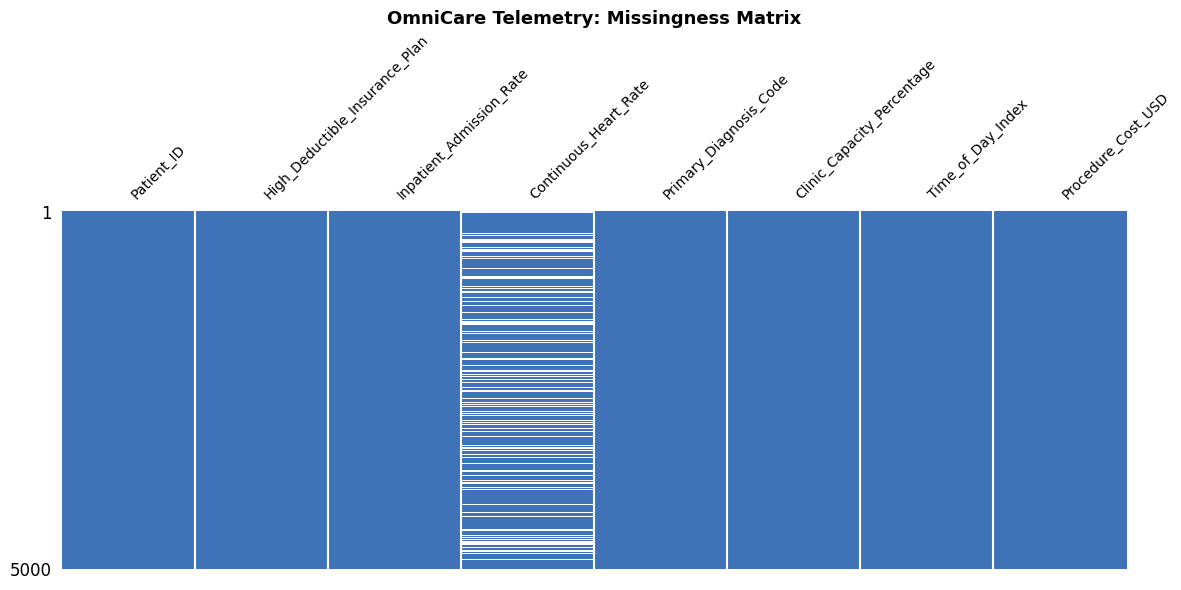

In [26]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv("OmniCare_Telemetry_Data.csv")

print(f"Dataset shape: {df.shape}")
print("\nMissing value counts:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

# missingness matrix plot
fig, ax = plt.subplots(figsize=(12, 6))
msno.matrix(df, ax=ax, sparkline=False, fontsize=10, color=(0.25, 0.45, 0.72))
ax.set_title("OmniCare Telemetry: Missingness Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("missingness_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

This is Missing Not At Random (MNAR) because the probability of
Continuous_Heart_Rate being missing is driven by income and socioeconomic status, which directly correlates with the unobserved heart rate values themselves. The sickest, lowest-income patients go silent precisely when their
readings would be most clinically abnormal.

The observed sample is a biased subset of healthier, higher-income
patients, so the imputed mean is systematically too low. Replacing
every missing value with this artificially healthy average compresses
the true variance, biases all downstream coefficients toward zero, and
causes the risk model to structurally underestimate patient risk.

Step 2.2: Escaping the Dummy Variable Trap

When you create a dummy for every category, one column is redundant because the 850 dummy columns always add up to the intercept column. In other words, you've given the model the same information twice. This makes the math unsolvable since there are infinite coefficient combinations that fit equally well. Fix it with `drop_first=True` to drop one reference category and break the perfect redundancy.

Step 2.3: Target Encoding Implementation

In [11]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [14]:
import pandas as pd
import category_encoders as ce

df = pd.read_csv("OmniCare_Telemetry_Data.csv")

print(f"Unique ICD-10 codes before encoding: {df['Primary_Diagnosis_Code'].nunique()}")

encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

df["Primary_Diagnosis_Code"] = encoder.fit_transform(
    df["Primary_Diagnosis_Code"],
    df["Procedure_Cost_USD"]
)

print("\nFirst 5 rows of encoded column:")
print(df[["Primary_Diagnosis_Code", "Procedure_Cost_USD"]].head())

Unique ICD-10 codes before encoding: 847

First 5 rows of encoded column:
   Primary_Diagnosis_Code  Procedure_Cost_USD
0             1707.697108             1635.84
1             1792.303198             1355.77
2             1730.334968             1189.19
3             1725.060944             1250.93
4             1801.821085             1986.34


## Phase 3: Architecting the Prediction Engine

Step 3.1: OLS Optimization via Patsy Formulas

In [17]:
import pandas as pd
import statsmodels.formula.api as smf
import category_encoders as ce

# load the datasets
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telem  = pd.read_csv("OmniCare_Telemetry_Data.csv")

# encode Primary_Diagnosis_Code
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
telem["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telem["Primary_Diagnosis_Code"],
    telem["Procedure_Cost_USD"]
)

# merge on patient id
df = pd.merge(vitals, telem, on="Patient_ID")

# identify necessary features (BMI dropped)
features = [
    "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]

target = "Procedure_Cost_USD"

df_model = df[features + [target]].dropna()

# ols formula
formula = ("Procedure_Cost_USD ~ Target_Encoded_Diagnosis + "
           "Clinic_Capacity_Percentage + Time_of_Day_Index + "
           "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP")

model  = smf.ols(formula=formula, data=df_model).fit()
print("\n")
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        01:41:18   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept         

Step 3.2: Financial Loss Quantification (RMSE)

In [18]:
from statsmodels.tools.eval_measures import rmse

y_true = df_model["Procedure_Cost_USD"]
y_pred = model.fittedvalues

model_rmse = rmse(y_true, y_pred)
print(f"RMSE: ${model_rmse:,.2f}")

RMSE: $334.80


An RMSE of \$450 on a \$1,200 procedure means the algorithm is routinely
wrong by 37.5% in either direction, a margin of error far too large
for real-world pricing decisions where patients, insurers, and regulators
expect accuracy. At this error rate, deploying the model live would
generate systematic overbilling, underbilling, and patient harm at a significant scale.

Step 3.3: Residual Diagnostics for Heteroscedasticity

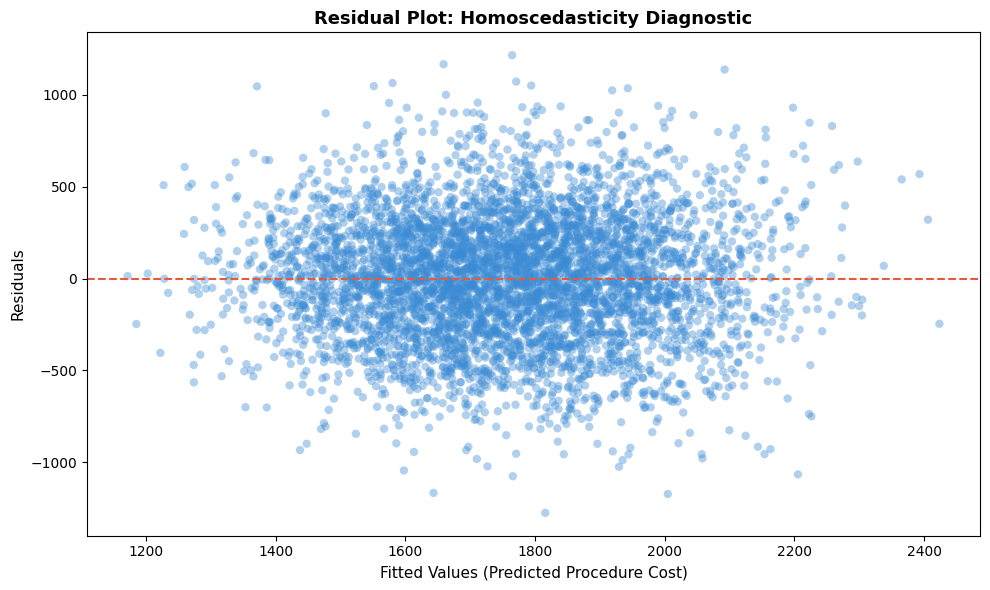

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals   = model.resid
fitted_vals = model.fittedvalues

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.4,
                color="#3B8BD4", edgecolor="none", ax=ax)

ax.axhline(0, color="#E8593C", linewidth=1.5, linestyle="--")
ax.set_xlabel("Fitted Values (Predicted Procedure Cost)", fontsize=11)
ax.set_ylabel("Residuals", fontsize=11)
ax.set_title("Residual Plot: Homoscedasticity Diagnostic",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

The residual plot shows a mild fan-out pattern as the spread of errors
widens slightly as fitted values increase toward the \$1,800–\$2,200 pricing range. This indicates mild heteroscedasticity, meaning
the model is systematically less reliable at high-cost predictions
precisely where pricing accuracy matters most, and standard errors
from the OLS summary are likely understated.

## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

Task 4.1: Lagrange Multiplier Test for Heteroscedasticity

**PRIME Prompt:**


**Persona**: You are an expert economist and Python engineer specializing
in OLS regression diagnostics for healthcare pricing models.

**Role**: Your role is to write a clean, executable Python script that performs
White's Lagrange Multiplier Test for heteroscedasticity on a fitted
statsmodels OLS model.

**Instructions**: Using the statsmodels.stats.diagnostic.het_white function,
write a script that extracts the residuals and fitted values from a
pre-fitted OLS model object called 'model' with a design matrix from
'df_model'. Run het_white and print the LM statistic, LM p-value, F-statistic,
and F p-value. Use only libraries already imported: pandas, numpy,
statsmodels.

**Meaning**: OmniCare Analytics is determining whether its dynamic medical
pricing algorithm violates the homoscedasticity assumption required for
valid OLS inference. A rejection of the null means all standard errors
and p-values in the model summary are untrustworthy and the model cannot
be safely deployed for live patient pricing.

**Evaluation**: The output must print clearly labeled test statistics, make
an explicit accept/reject decision at the 0.05 significance level, and
include a one-sentence plain-English interpretation of what the result
means for model deployment.

In [25]:
# ============================================================
# Step 4.1: White's LM Test for Heteroscedasticity
# ============================================================
from statsmodels.stats.diagnostic import het_white
import numpy as np

residuals = model.resid.values
X_matrix  = model.model.exog

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(residuals, X_matrix)

print("=== White's LM Test for Heteroscedasticity ===")
print(f"LM Statistic:  {lm_stat:.4f}")
print(f"LM p-value:    {lm_pvalue:.4f}")
print(f"F-Statistic:   {f_stat:.4f}")
print(f"F p-value:     {f_pvalue:.4f}")
print()

if lm_pvalue < 0.05:
    print("Decision: REJECT null hypothesis of homoscedasticity (p < 0.05).")
    print("The variance of residuals is non-constant — standard errors in "
          "the OLS summary are invalid and the model cannot be safely "
          "deployed for live pricing decisions.")
else:
    print("Decision: FAIL TO REJECT null hypothesis of homoscedasticity (p >= 0.05).")
    print("No significant evidence of heteroscedasticity detected.")

=== White's LM Test for Heteroscedasticity ===
LM Statistic:  186.4677
LM p-value:    0.0000
F-Statistic:   5.4942
F p-value:     0.0000

Decision: REJECT null hypothesis of homoscedasticity (p < 0.05).
The variance of residuals is non-constant — standard errors in the OLS summary are invalid and the model cannot be safely deployed for live pricing decisions.
